In [28]:
from utilities import*
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from tqdm import tqdm

In [46]:
X_train, y_train, X_test, y_test = load_data()

In [15]:
print(X_train.shape)
print(y_train.shape)
print(np.unique(y_train,return_counts=True))

(1000, 64, 64)
(1000, 1)
(array([0., 1.]), array([500, 500]))


In [16]:
print(X_test.shape)
print(y_test.shape)
print(np.unique(y_train,return_counts=True))

(200, 64, 64)
(200, 1)
(array([0., 1.]), array([500, 500]))


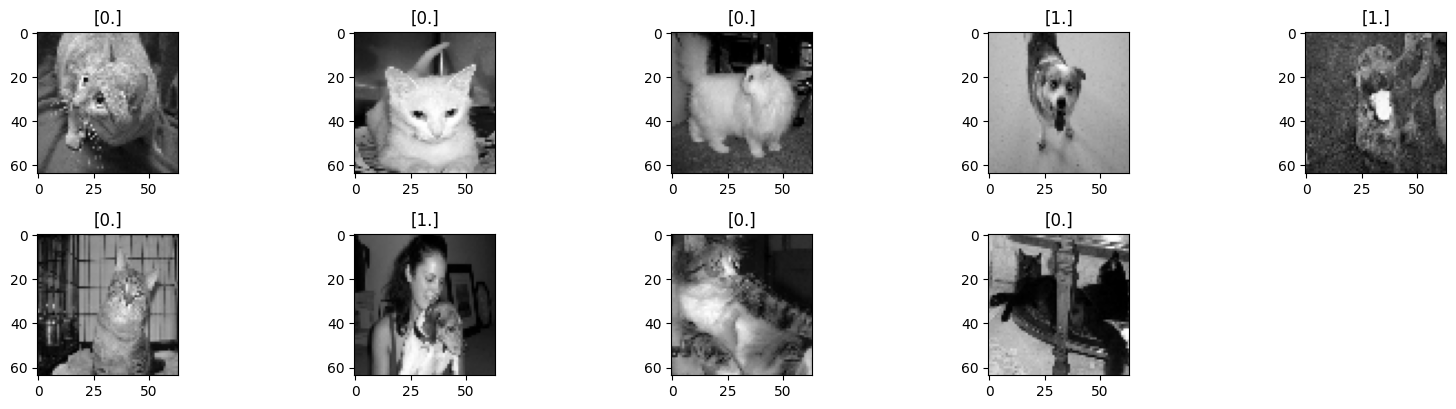

In [17]:
#display some sample image datasets
plt.figure(figsize=(16,8))
for i in range (1,10):
    plt.subplot(4,5,i)
    plt.imshow(X_train[i],cmap='gray')
    plt.title(y_train[i])
    plt.tight_layout()
plt.show()    

In [18]:
def initialisation(X):
    W = np.random.randn(X.shape[1], 1)
    b = np.random.randn(1)
    return (W, b)

In [19]:
def normalise(X):
    return X/255.0


In [20]:
def flatten(X):
    return X.reshape(X.shape[0], -1)


In [21]:
def model(X, W, b):
    Z = X.dot(W) + b
    A = 1 / (1 + np.exp(-Z))
    return A

In [22]:
def logloss(A, y):
    #Bonne pratique pour eviter de calculer des log en 0
    epsilon = 1e-15
    return 1 / len(y) * np.sum(-y * np.log(A+epsilon) - (1 - y) * np.log(1 - A+epsilon))

In [23]:
def gradients(A,X,y):
    dW = 1 / len(y) * np.dot(X.T, A - y)
    db = 1 / len(y) * np.sum(A - y)
    return (dW, db)

In [24]:
def update_gradient(dW, db , W , b , lr):
    W = W - lr * dW
    b = b - lr * db
    return (W, b) 

In [34]:
def predict(X, W, b):
    A = model(X, W, b)
    # print(A)
    return A >= 0.5

In [47]:
def compute(X_train, y_train, X_test, y_test, learning_rate = 0.01, n_iter = 10000):
    # initialisation W, b
    W, b = initialisation(X_train)

    train_loss = []
    train_acc = []
    test_loss = []
    test_acc = []

    # tqdm use only for the progress bar 
    for i in tqdm(range(n_iter)):
        A = model(X_train, W, b)

        if i %10 == 0:
            # Train
            train_loss.append(logloss(A, y_train))
            y_pred = predict(X_train, W, b)
            train_acc.append(accuracy_score(y_train, y_pred))

            # Test
            A_test = model(X_test, W, b)
            test_loss.append(logloss(A_test, y_test))
            y_pred = predict(X_test, W, b)
            test_acc.append(accuracy_score(y_test, y_pred))

        # mise a jour
        dW, db = gradients(A, X_train, y_train)
        W, b = update_gradient(dW, db, W, b, learning_rate)


    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(train_loss, label='train loss')
    plt.plot(test_loss, label='test loss')
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(train_acc, label='train acc')
    plt.plot(test_acc, label='test acc')
    plt.legend()
    plt.show()

    return (W, b)

100%|███████████████████████████████████████████████████████████████████████████| 10000/10000 [00:22<00:00, 440.27it/s]


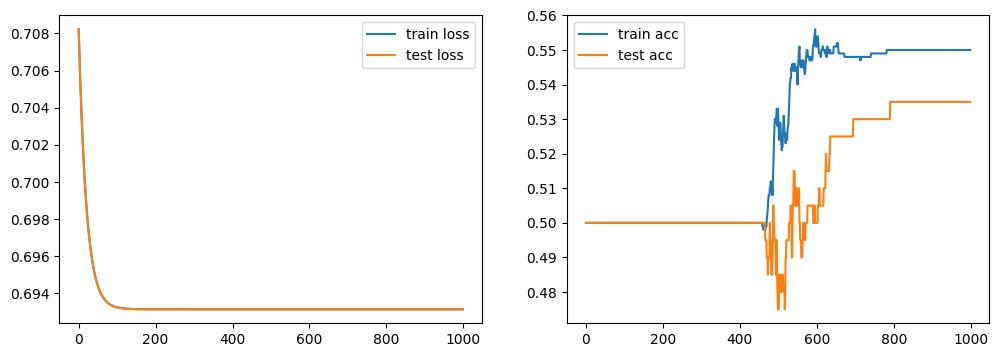

In [51]:
X_train = flatten(X_train) 
X_test = flatten(X_test) 
X_train = normalise(X_train) 
X_test = normalise(X_test) 
W,b = compute(X_train,y_train , X_test , y_test)